In [3]:
import os
from pathlib import Path

# Setup environment if we are in google colab
USING_COLAB = "google.colab" in str(get_ipython())
if USING_COLAB:
  # Installing packages
  !pip install utide --quiet
  !pip install ipympl --quiet
  !pip freeze > requirements.txt

  # 3rd party widgets
  from google.colab import output
  output.enable_custom_widget_manager()

  # Downloading the repository with data/codes
  if not Path("polm2026").exists():
    !git clone https://github.com/jamal919/polm2026

In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import utide

if USING_COLAB:
    %matplotlib widget

# Data sources
* Research quality data: https://uhslc.soest.hawaii.edu/data/?rq.html
* Fast delivery data: https://uhslc.soest.hawaii.edu/data/?fd 

In [6]:
!wget -c "https://uhslc.soest.hawaii.edu/data/csv/rqds/indian/hourly/h134a.csv" -O uhslc_hiron_point.csv

--2026-08-07 22:12:33--  https://uhslc.soest.hawaii.edu/data/csv/rqds/indian/hourly/h134a.csv
Resolving uhslc.soest.hawaii.edu (uhslc.soest.hawaii.edu)... 128.171.46.212
Connecting to uhslc.soest.hawaii.edu (uhslc.soest.hawaii.edu)|128.171.46.212|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 4115879 (3.9M) [application/octet-stream]
Saving to: ‘uhslc_hiron_point.csv’

uhslc_hiron_point.c 100%[===================>]   3.92M  2.45MB/s    in 1.6s    

2026-08-07 22:12:36 (2.45 MB/s) - ‘uhslc_hiron_point.csv’ saved [4115879/4115879]



In [7]:
def uhslc_read(fn) -> pd.DataFrame:
  """
  Read UHSLC data from a file and return a pandas dataframe.
  """
  df = pd.read_csv(
      fn, 
      header=None, 
      names=["Year", "Month", "Day", "Hour", "Elev"], 
      na_values=[-9999, 9999, -32767]
      )
  datetime = pd.to_datetime(
      df.apply(
          lambda r: f"{int(r.Year):04d}-{int(r.Month):02d}-{int(r.Day):02d} {int(r.Hour):02d}:00:00", 
          axis=1)
      )
  df = df.loc[:, ["Elev"]].assign(Datetime=datetime).set_index("Datetime")
  df = df/1000 # mm -> m
  return df

In [9]:
fn = "uhslc_hiron_point.csv"
df = uhslc_read(fn)

In [48]:
coef = utide.solve(df.index, df.Elev, lat=21, verbose=False, nodal=True)
df = df.assign(Tide=utide.reconstruct(t=df.index, coef=coef, verbose=False)["h"])
df = df.assign(Surge=df.Elev-df.Tide)

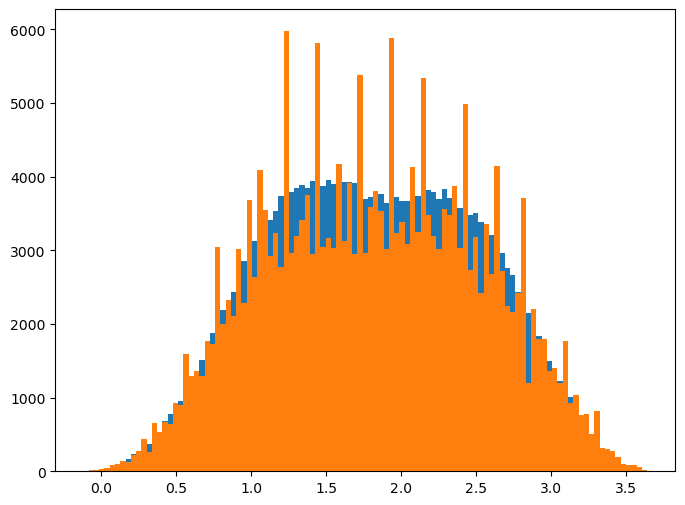

In [49]:
fig, ax = plt.subplots(figsize=(8, 6))
freq, bins, _ = ax.hist(df.Tide, bins="fd")
ax.hist(df.Elev, bins=bins)
plt.show()

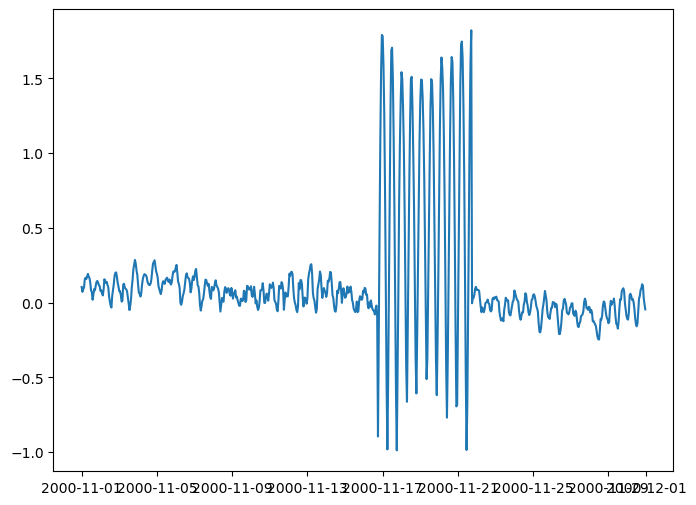

In [53]:
fig, ax = plt.subplots(figsize=(8, 6))
ax.plot(df.loc["2000-11"].index, df.loc["2000-11"].Surge)
plt.show()

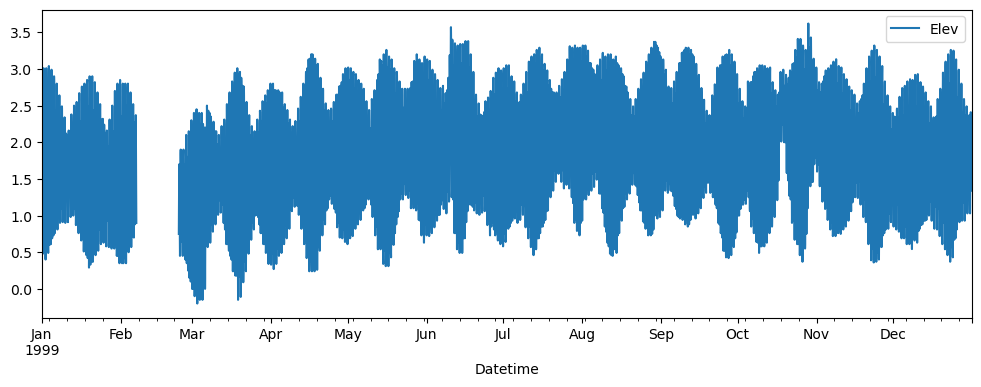

In [16]:
fig, ax = plt.subplots(figsize=(12, 4))
df.loc["1999"].plot(ax=ax)
plt.show()

<Axes: xlabel='Datetime'>

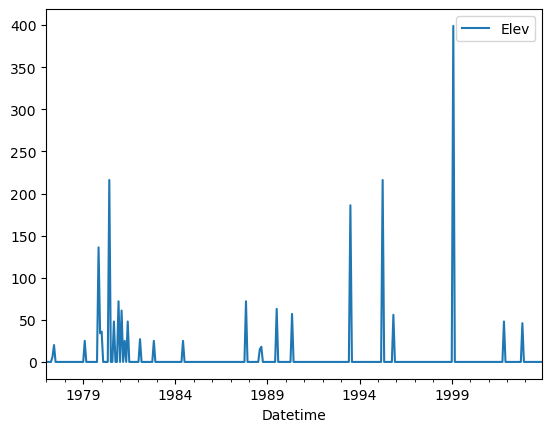

In [17]:
df1 = df.resample("D").apply(lambda x: np.sum(np.isnan(x)))
df2 = df1.resample("MS").apply(lambda x: np.sum(x))
df2.plot()